# DO Masked Card Classifier Test Notebook

Run scene segmentation, detect card crops, classify each crop with a mask-conditioned classifier, and group predictions with fixed UNO geometry (`p1` bottom, `p2` right, `p3` top, `p4` left, center in the middle).

## Inference conventions

- This notebook is inference/evaluation only.
- It loads:
  - `project/models/scene_segmenter_unet_small.pth`
  - `project/models/card_classifier_masked_resnet18_do.pth`
  - `project/models/card_classifier_masked_resnet18_classes_do.npy`
  - `project/models/card_classifier_masked_resnet18_config_do.json`
- It does not use pretrained external weights and keeps the existing competition-compliant geometry mapping.

In [1]:
from pathlib import Path
import sys

candidate_src_dirs = [
    Path.cwd() / "src",
    Path.cwd().parent.parent / "src",
]
for src_dir in candidate_src_dirs:
    if src_dir.is_dir():
        parent = src_dir.parent.resolve()
        if str(parent) not in sys.path:
            sys.path.insert(0, str(parent))
        break
else:
    raise FileNotFoundError("Could not locate do/src directory for imports.")


from src.test_classifier_CNN import (
    TestPipelineConfig,
    initialize_test_pipeline,
    run_labeled_benchmark,
    run_single_image_diagnostics,
)

# Most-used quick knobs
IMAGE_SOURCE = "augmented_scene"
IMAGE_INDEX = 0
IMAGE_ID = None
SEGMENTATION_THRESHOLD = 0.50
CARD_MASK_THRESHOLD = 0.50
CARD_IMG_SIZE = 160
SEGMENTER_IMG_SIZE = 256

EVAL_MAX_IMAGES = None
EVAL_RANDOM_SUBSET = True
EVAL_SEED = 42
WORST_K = 7
TOP_K = 7

TEST_CFG = TestPipelineConfig(
    image_source=IMAGE_SOURCE,
    image_index=IMAGE_INDEX,
    image_id=IMAGE_ID,
    card_img_size=CARD_IMG_SIZE,
    segmenter_img_size=SEGMENTER_IMG_SIZE,
    card_mask_threshold=CARD_MASK_THRESHOLD,
    eval_threshold=SEGMENTATION_THRESHOLD,
)

BENCHMARK_CFG = {
    "eval_max_images": EVAL_MAX_IMAGES,
    "eval_random_subset": EVAL_RANDOM_SUBSET,
    "eval_seed": EVAL_SEED,
    "eval_threshold": TEST_CFG.eval_threshold,
    "worst_k": WORST_K,
    "top_k": TOP_K,
}

TEST_CFG

TestPipelineConfig(image_source='augmented_scene', image_index=0, image_id=None, card_img_size=160, segmenter_img_size=256, card_mask_threshold=0.5, eval_threshold=0.5)

## Shared Helpers

In [2]:
test_state = initialize_test_pipeline(TEST_CFG)
{
    "image_id": test_state["image_id"],
    "image_path": str(test_state["image_path"]),
    "image_shape": (test_state["image_w"], test_state["image_h"]),
}

Project root: /Users/dorianbesson/EDOC/IA/iapr2026do
Segmenter:    /Users/dorianbesson/EDOC/IA/iapr2026do/project/models/segmenter/used/scene_segmenter_unet_small.pth
Classifier bundle: /Users/dorianbesson/EDOC/IA/iapr2026do/project/models/card_classifier_cnn/used/latest
Classifier:   /Users/dorianbesson/EDOC/IA/iapr2026do/project/models/card_classifier_cnn/used/latest/card_classifier.pth
[compliance] SceneUNetSmall (segmenter): 1,928,417 trainable params
[compliance] CardClassifier[resnet18_small]: 9,853,134 trainable params
Loaded masked classifier with 54 classes.
Classifier architecture: resnet18_small (stem_width=60)
Card image size: 160 | mask threshold: 0.5 | input channels: 4
Device: cpu
Image source: augmented_scene
Image id:     aug_scene_00000
Image shape:  1280 x 720
Truth cards:  13, active: p2


{'image_id': 'aug_scene_00000',
 'image_path': '/Users/dorianbesson/EDOC/IA/iapr2026do/project/training_data/training_images/augmented_scenes/aug_scene_00000.jpg',
 'image_shape': (1280, 720)}

## Segmenter Helpers

Detected boxes: 13
Foreground pixels: 107252


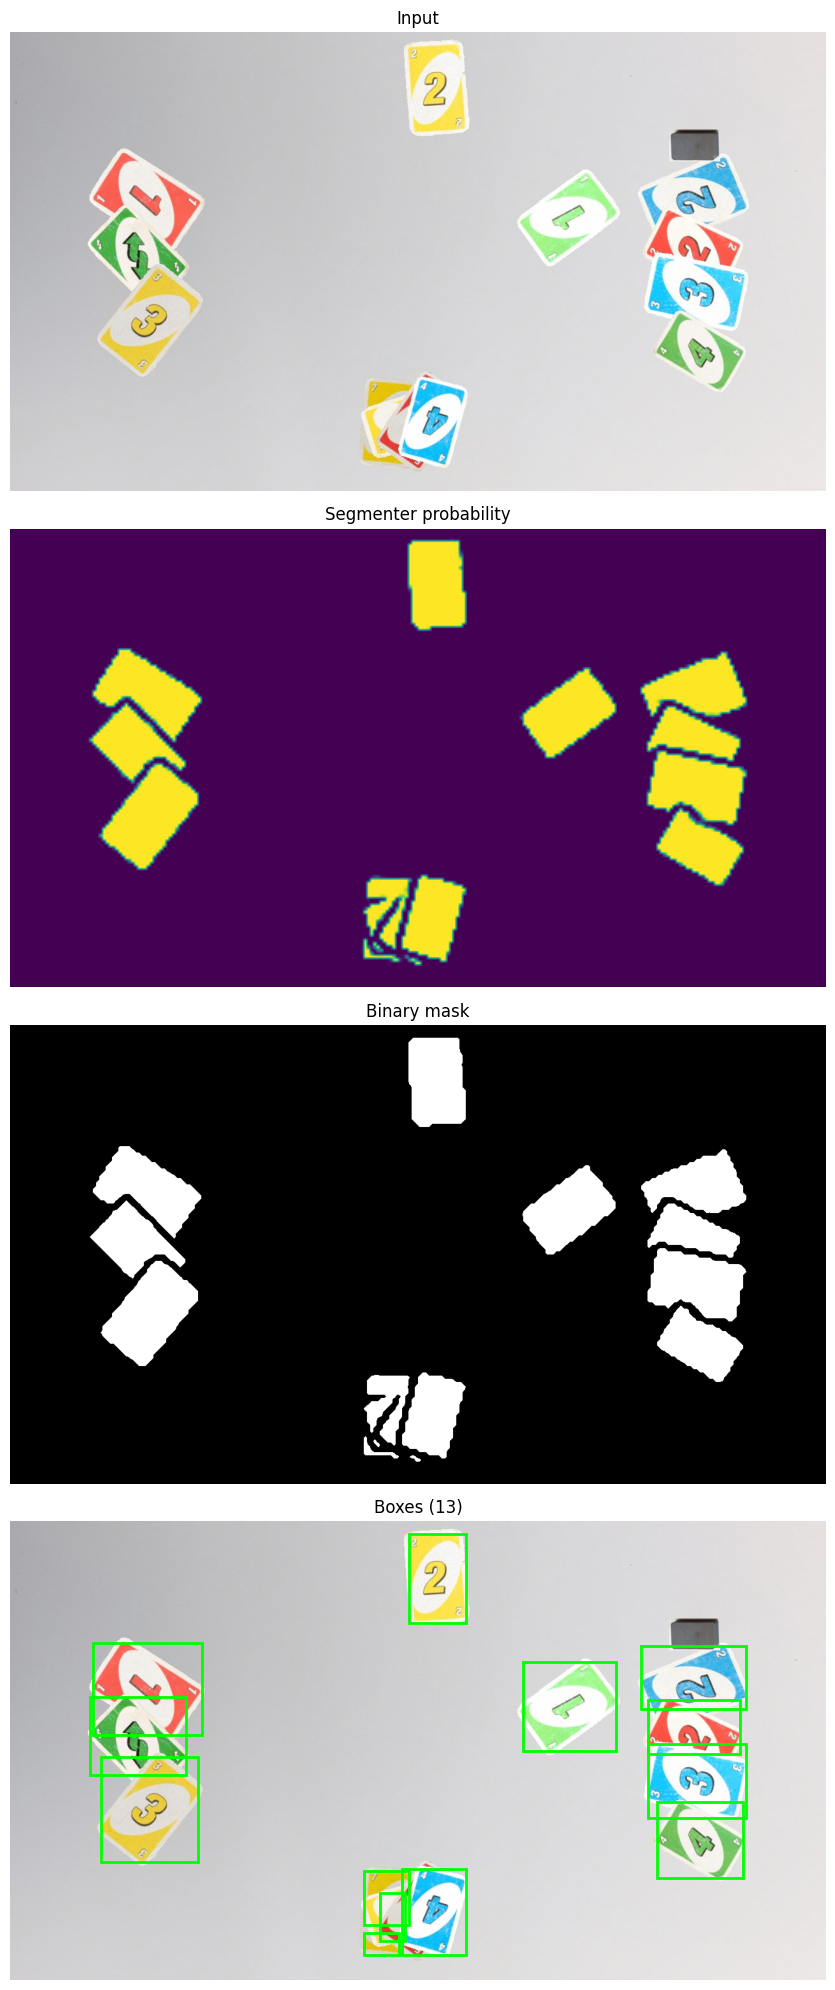

Predictions:
  box 00 (142, 370, 295, 535) -> y_3 [p4] conf=0.96 mask_cov=0.43
  box 01 (130, 190, 300, 335) -> r_1 [p4] conf=0.46 mask_cov=0.43
  box 02 (804, 220, 950, 360) -> g_1 [p2] conf=0.98 mask_cov=0.39
  box 03 (125, 275, 275, 398) -> g_reverse [p4] conf=0.74 mask_cov=0.49
  box 04 (1000, 350, 1155, 465) -> b_3 [p2] conf=0.87 mask_cov=0.48
  box 05 (990, 195, 1155, 295) -> b_2 [p2] conf=0.39 mask_cov=0.31
  box 06 (1015, 440, 1150, 560) -> g_4 [p2] conf=0.92 mask_cov=0.46
  box 07 (615, 545, 715, 680) -> b_4 [p1] conf=0.96 mask_cov=0.41
  box 08 (625, 20, 715, 160) -> y_2 [p3] conf=0.99 mask_cov=0.44
  box 09 (1000, 280, 1145, 365) -> r_2 [p2] conf=0.19 mask_cov=0.39
  box 10 (555, 549, 626, 633) -> y_1 [p1] conf=0.19 mask_cov=0.47
  box 11 (580, 583, 620, 658) -> y_1 [p1] conf=0.17 mask_cov=0.33
  box 12 (555, 645, 610, 680) -> y_6 [p1] conf=0.18 mask_cov=0.21


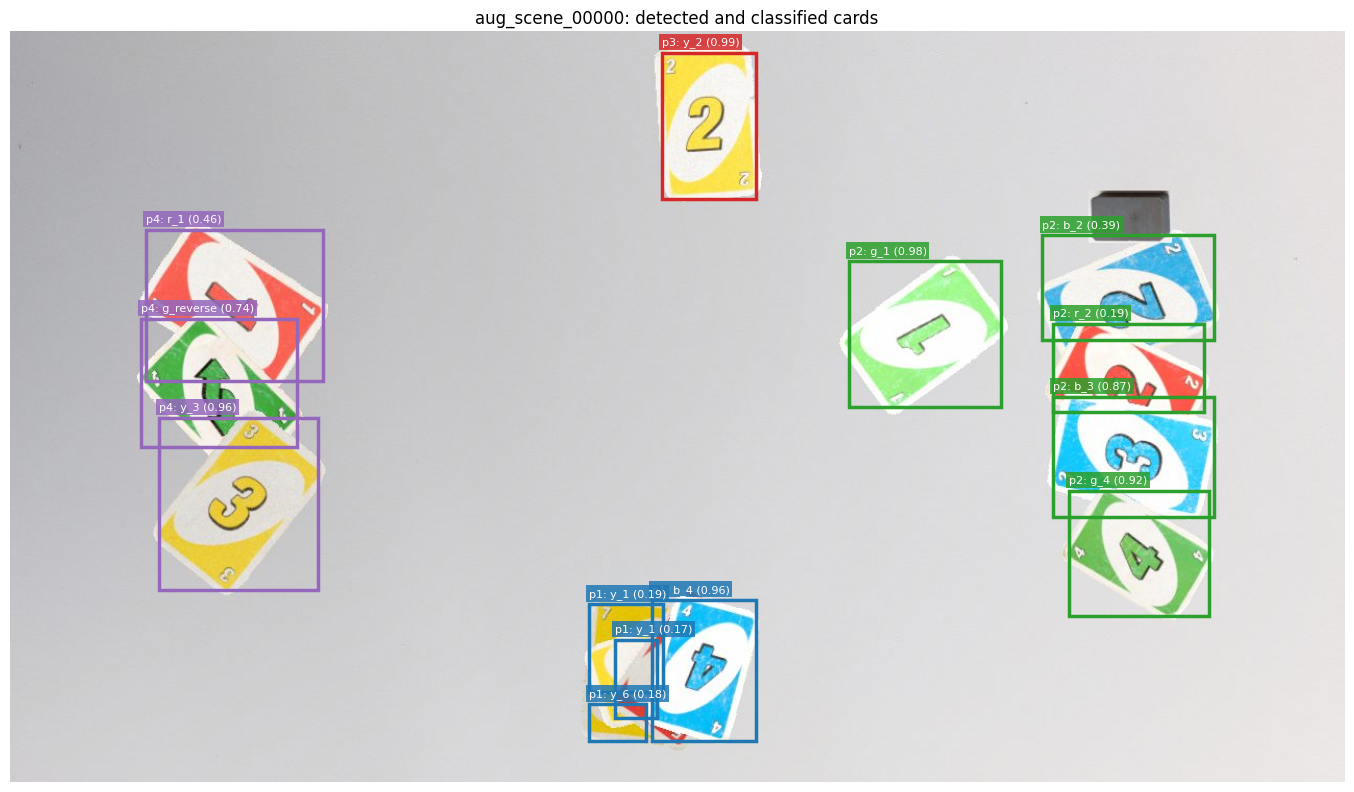


Matched IoU >= 0.30: 11 / 13
Label accuracy on matched boxes:        90.9%
Owner/region accuracy on matched boxes: 90.9%

First matched rows:
  pred=p4     y_3          | truth=p4     y_3          | IoU=0.85
  pred=p4     r_1          | truth=p4     r_1          | IoU=0.84
  pred=p2     g_1          | truth=center g_1          | IoU=0.82
  pred=p4     g_reverse    | truth=p4     g_reverse    | IoU=0.72
  pred=p2     b_3          | truth=p2     b_3          | IoU=0.88
  pred=p2     b_2          | truth=p2     b_2          | IoU=0.65
  pred=p2     g_4          | truth=p2     g_4          | IoU=0.86
  pred=p1     b_4          | truth=p1     b_4          | IoU=0.87
  pred=p3     y_2          | truth=p3     y_2          | IoU=0.80
  pred=p2     r_2          | truth=p2     r_2          | IoU=0.59
  pred=p1     y_1          | truth=p1     y_7          | IoU=0.42
  pred=p1     y_1          | truth=p1     y_7          | IoU=0.21
  pred=p1     y_6          | truth=p1     y_7          | IoU=0.14

{'image_id': 'aug_scene_00000',
 'center_card': 'EMPTY',
 'active_player': 'p2',
 'player_1_cards': 'b_4;y_1;y_1;y_6',
 'player_2_cards': 'g_1;b_3;b_2;g_4;r_2',
 'player_3_cards': 'y_2',
 'player_4_cards': 'y_3;r_1;g_reverse'}

In [3]:
test_state = run_single_image_diagnostics(test_state, threshold=TEST_CFG.eval_threshold)
test_state.get("summary", {})

## Load Segmenter + Masked Classifier And Pick An Image

In [4]:
test_state.get("pred_rows", [])[:10]

[{'box_index': 0,
  'box': (142, 370, 295, 535),
  'label': 'y_3',
  'confidence': 0.961736798286438,
  'region': 'p4',
  'mask_coverage': 0.4314453125},
 {'box_index': 1,
  'box': (130, 190, 300, 335),
  'label': 'r_1',
  'confidence': 0.4618473947048187,
  'region': 'p4',
  'mask_coverage': 0.4294140625},
 {'box_index': 2,
  'box': (804, 220, 950, 360),
  'label': 'g_1',
  'confidence': 0.9792400598526001,
  'region': 'p2',
  'mask_coverage': 0.38640625},
 {'box_index': 3,
  'box': (125, 275, 275, 398),
  'label': 'g_reverse',
  'confidence': 0.7371623516082764,
  'region': 'p4',
  'mask_coverage': 0.493203125},
 {'box_index': 4,
  'box': (1000, 350, 1155, 465),
  'label': 'b_3',
  'confidence': 0.869304358959198,
  'region': 'p2',
  'mask_coverage': 0.4769140625},
 {'box_index': 5,
  'box': (990, 195, 1155, 295),
  'label': 'b_2',
  'confidence': 0.38683053851127625,
  'region': 'p2',
  'mask_coverage': 0.3070703125},
 {'box_index': 6,
  'box': (1015, 440, 1150, 560),
  'label': 'g_

In [5]:
test_state.get("summary", {})

{'image_id': 'aug_scene_00000',
 'center_card': 'EMPTY',
 'active_player': 'p2',
 'player_1_cards': 'b_4;y_1;y_1;y_6',
 'player_2_cards': 'g_1;b_3;b_2;g_4;r_2',
 'player_3_cards': 'y_2',
 'player_4_cards': 'y_3;r_1;g_reverse'}

## Segment Cards

In [6]:
BENCHMARK_CFG

{'eval_max_images': None,
 'eval_random_subset': True,
 'eval_seed': 42,
 'eval_threshold': 0.5,
 'worst_k': 7,
 'top_k': 7}

## Classify Masked Card Crops And Group By Table Geometry

Evaluating on 71 labeled original images from /Users/dorianbesson/EDOC/IA/iapr2026do/data/iapr-26-uno-vision-challenge/train.csv...
  processed 25/71
  processed 50/71
  processed 71/71

Benchmark summary (masked classifier on original labeled data):
  Center-card accuracy: 97.18%
  Player F1: p1=0.827, p2=0.835, p3=0.832, p4=0.814
  Macro player F1: 0.827
  Overall image score:  0.856
  Overall strict score: 0.861 (includes segmenter count-variation quality)
  Segmenter avg |pred-true| cards/image: 0.254
  Segmenter avg (pred-true) cards/image: 0.056
  Segmenter avg region variation/image:  0.310
  Segmenter total cards: pred=560, true=556
  Segmenter count-quality score: 0.887
  Note: active_player is not scored yet (not predicted by this pipeline).


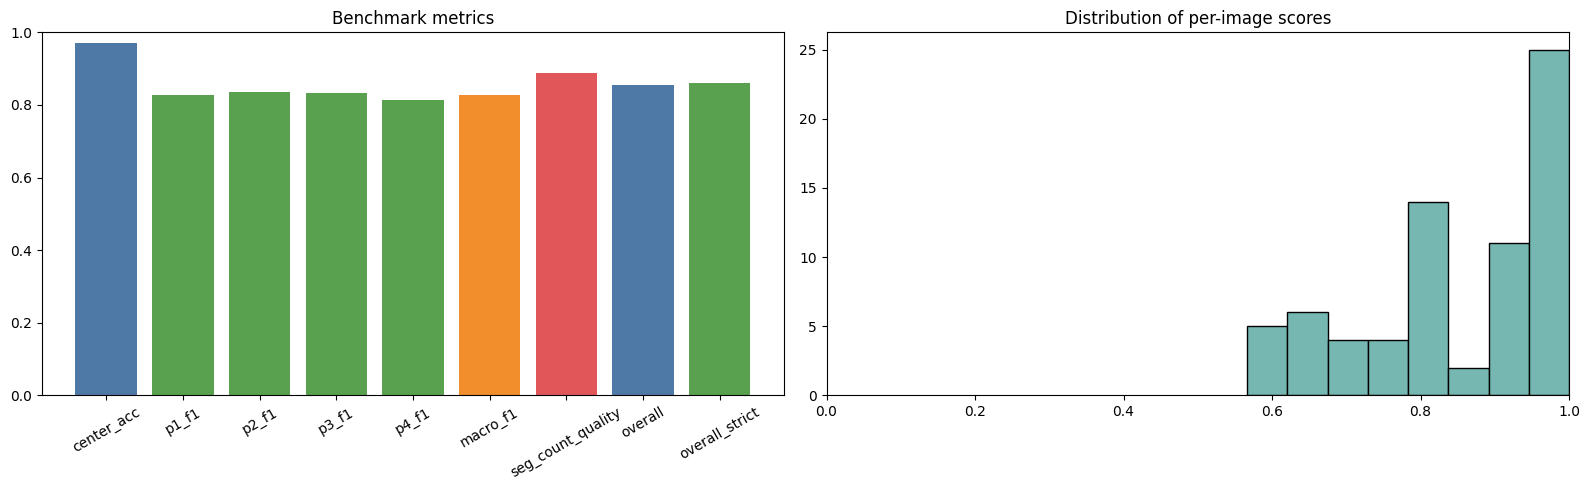


Worst-performing labeled images:
  L1000839: score=0.567, center(pred/true)=b_7/b_1
  L1000978: score=0.567, center(pred/true)=y_8/y_8
  L1000981: score=0.567, center(pred/true)=b_5/b_5
  L1000983: score=0.580, center(pred/true)=b_skip/b_skip
  L1000975: score=0.581, center(pred/true)=y_3/y_3
  L1000982: score=0.633, center(pred/true)=y_4/y_4
  L1000850: score=0.648, center(pred/true)=g_2/g_2

Top-performing labeled images:
  L1000770: score=1.000, center(pred/true)=y_1/y_1
  L1000771: score=1.000, center(pred/true)=r_5/r_5
  L1000773: score=1.000, center(pred/true)=y_8/y_8
  L1000774: score=1.000, center(pred/true)=r_4/r_4
  L1000778: score=1.000, center(pred/true)=b_9/b_9
  L1000781: score=1.000, center(pred/true)=g_8/g_8
  L1000782: score=1.000, center(pred/true)=y_7/y_7


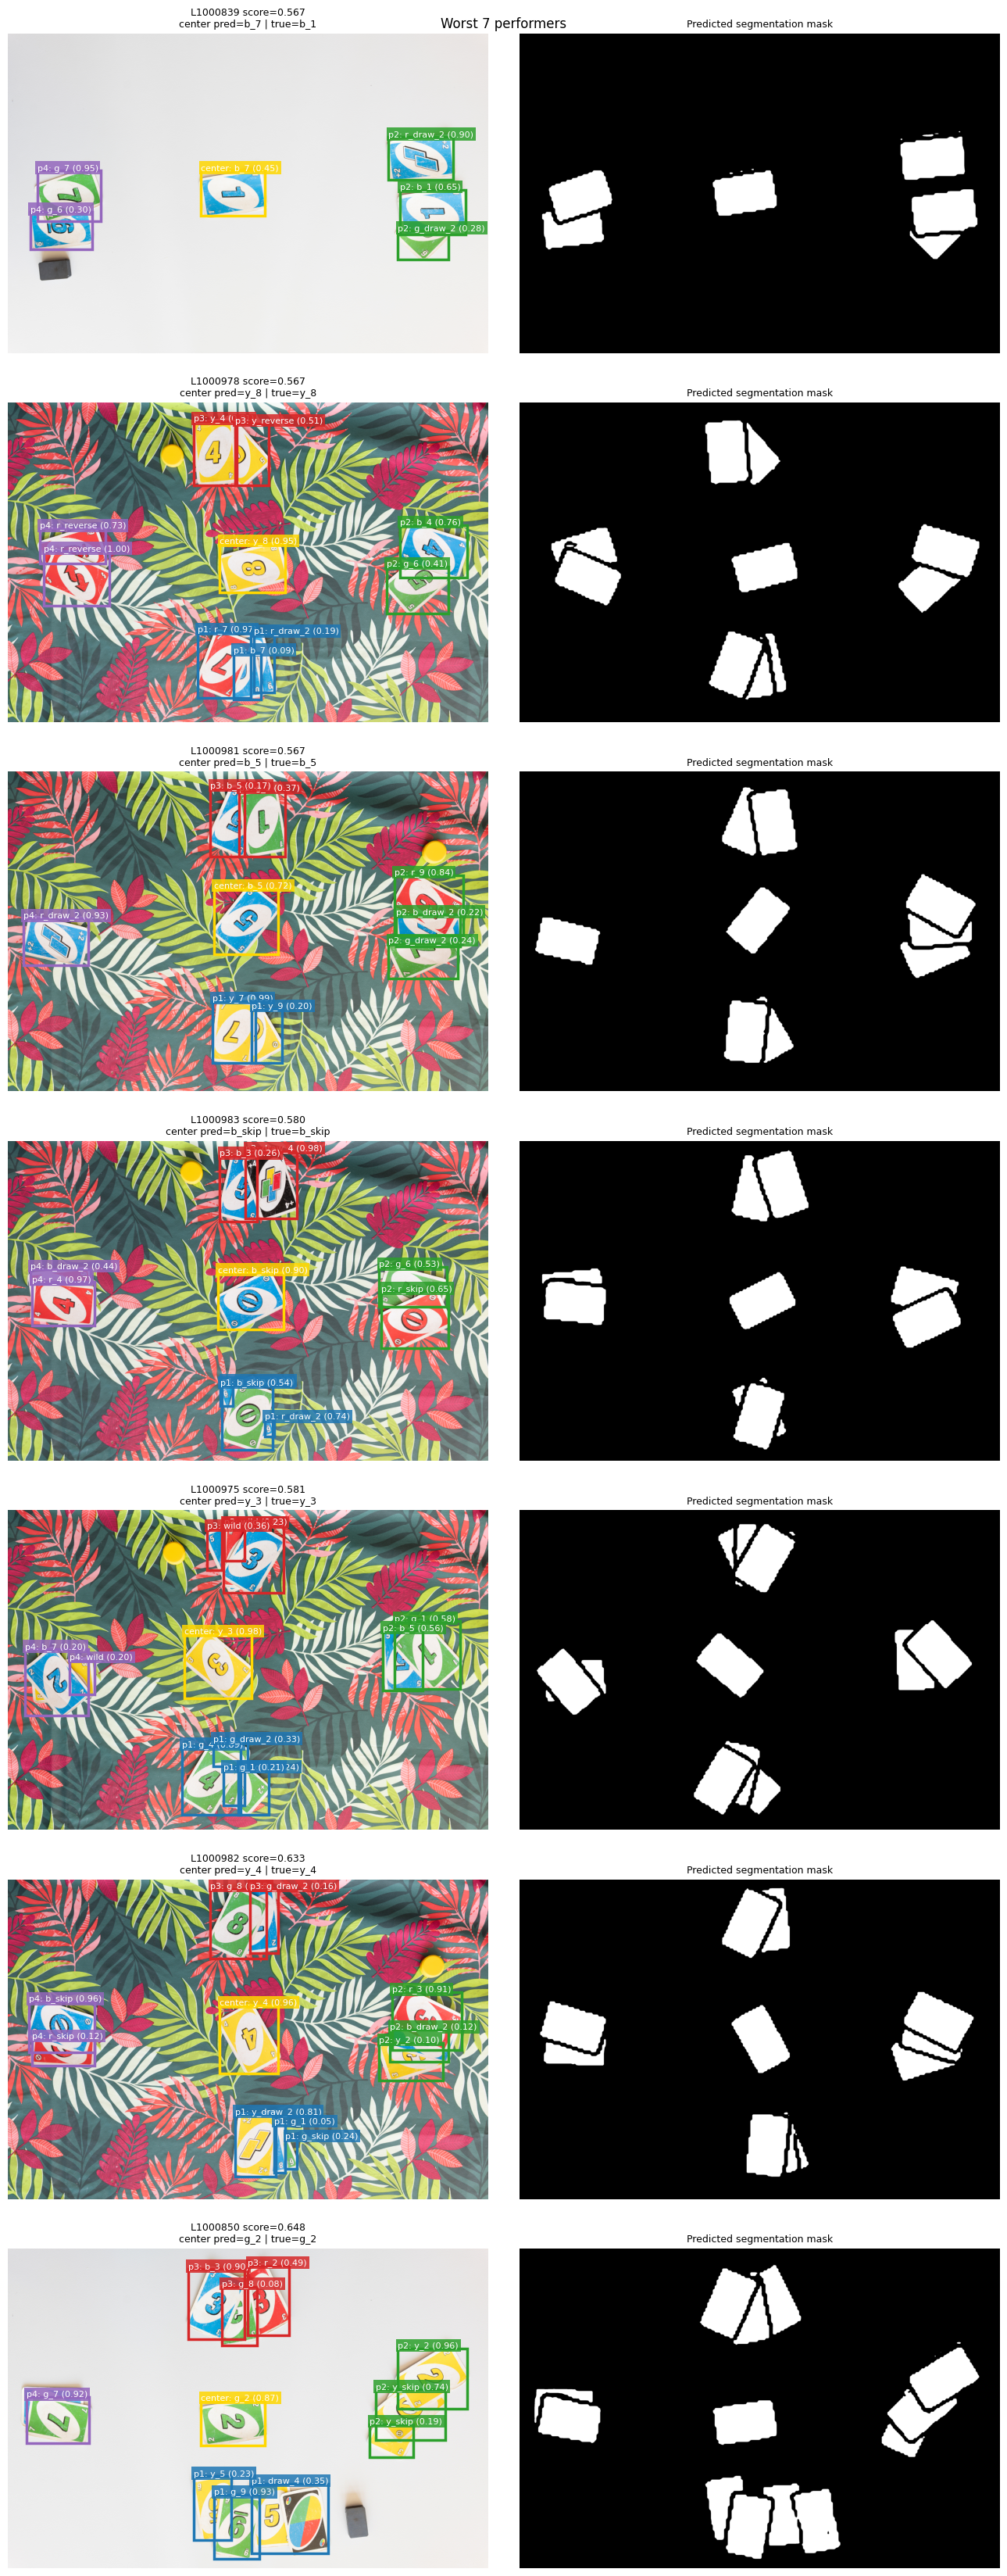

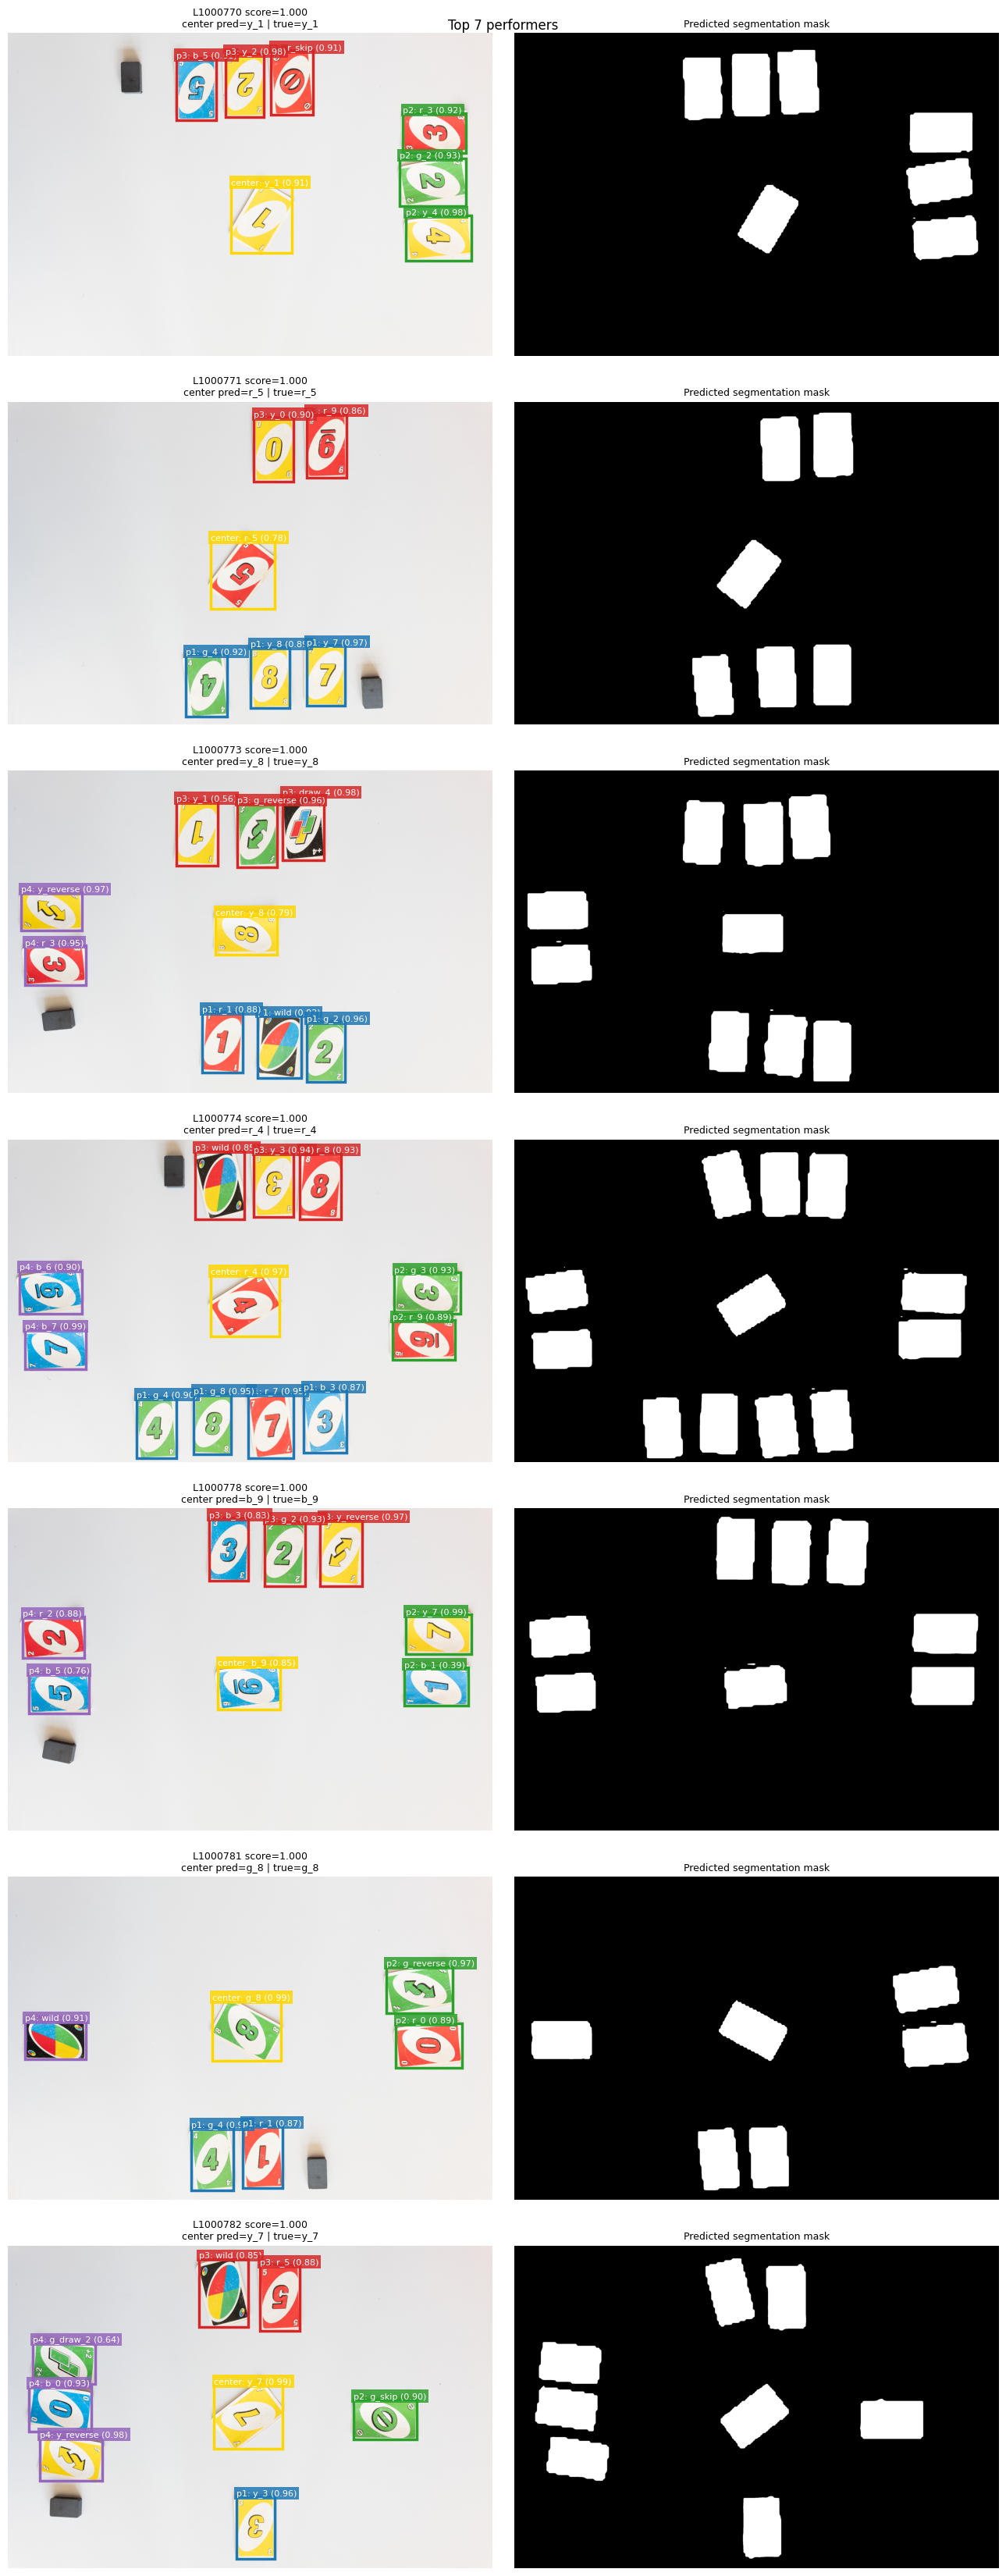

{'center_acc': 0.971830985915493,
 'p1_f1': 0.826559356136821,
 'p2_f1': 0.8354460093896715,
 'p3_f1': 0.83242790073776,
 'p4_f1': 0.8140845070422534,
 'macro_f1': 0.8271294433266264,
 'overall': 0.8560697518443998,
 'overall_strict': 0.861278783813995,
 'segmenter_count_quality': 0.8873239436619719,
 'avg_abs_card_count_diff': 0.2535211267605634,
 'avg_signed_card_count_diff': 0.056338028169014086,
 'avg_region_abs_card_count_diff': 0.30985915492957744,
 'cards_total_true': 556,
 'cards_total_pred': 560}

In [7]:
benchmark = run_labeled_benchmark(test_state, BENCHMARK_CFG)
{
    key: benchmark[key]
    for key in [
        "center_acc", "p1_f1", "p2_f1", "p3_f1", "p4_f1",
        "macro_f1", "overall", "overall_strict",
        "segmenter_count_quality", "avg_abs_card_count_diff",
        "avg_signed_card_count_diff", "avg_region_abs_card_count_diff",
        "cards_total_true", "cards_total_pred",
    ]
}

## Synthetic-Scene Check

In [8]:
benchmark["worst_results"][:5]

[{'image_id': 'L1000839',
  'image_path': PosixPath('/Users/dorianbesson/EDOC/IA/iapr2026do/data/iapr-26-uno-vision-challenge/train_images/L1000839.jpg'),
  'pred_summary': {'image_id': 'L1000839',
   'center_card': 'b_7',
   'active_player': 'unknown',
   'player_1_cards': 'EMPTY',
   'player_2_cards': 'b_1;r_draw_2;g_draw_2',
   'player_3_cards': 'EMPTY',
   'player_4_cards': 'g_7;g_6'},
  'true_summary': {'image_id': 'L1000839',
   'center_card': 'b_1',
   'active_player': 'p4',
   'player_1_cards': 'EMPTY',
   'player_2_cards': 'b_draw_2;b_1;g_6',
   'player_3_cards': 'EMPTY',
   'player_4_cards': 'g_7;b_6'},
  'pred_rows': [{'box_index': 0,
    'box': (244, 1143, 773, 1566),
    'label': 'g_7',
    'confidence': 0.9514235258102417,
    'region': 'p4',
    'mask_coverage': 0.4687890625},
   {'box_index': 1,
    'box': (3265, 1300, 3812, 1675),
    'label': 'b_1',
    'confidence': 0.6489853262901306,
    'region': 'p2',
    'mask_coverage': 0.44234375},
   {'box_index': 2,
    'box

## Game-State Style Summary

This formats CardUNet predictions into the same game-state style row structure:
one center card and one card list per player (`p1..p4`). Active-player prediction remains handled by the turn/token detector.

In [9]:
benchmark["top_results"][:5]

[{'image_id': 'L1000770',
  'image_path': PosixPath('/Users/dorianbesson/EDOC/IA/iapr2026do/data/iapr-26-uno-vision-challenge/train_images/L1000770.jpg'),
  'pred_summary': {'image_id': 'L1000770',
   'center_card': 'y_1',
   'active_player': 'unknown',
   'player_1_cards': 'EMPTY',
   'player_2_cards': 'g_2;y_4;r_3',
   'player_3_cards': 'r_skip;b_5;y_2',
   'player_4_cards': 'EMPTY'},
  'true_summary': {'image_id': 'L1000770',
   'center_card': 'y_1',
   'active_player': 'p3',
   'player_1_cards': 'EMPTY',
   'player_2_cards': 'y_4;g_2;r_3',
   'player_3_cards': 'r_skip;y_2;b_5',
   'player_4_cards': 'EMPTY'},
  'pred_rows': [{'box_index': 0,
    'box': (1844, 1253, 2344, 1816),
    'label': 'y_1',
    'confidence': 0.9072479605674744,
    'region': 'center',
    'mask_coverage': 0.3671875},
   {'box_index': 1,
    'box': (3234, 1033, 3782, 1425),
    'label': 'g_2',
    'confidence': 0.9315499067306519,
    'region': 'p2',
    'mask_coverage': 0.401484375},
   {'box_index': 2,
    '

## Benchmark On Original Labeled Dataset (Masked Classifier)

> The official `test_images` split has no public labels, so true performance cannot be computed there. This section evaluates the full segmentation + masked classification pipeline on labeled images from `train.csv` (optionally on a subset), reports metrics, and visualizes worst/top examples.

In [10]:
# # Optional quick benchmark rerun on a subset.
# quick_benchmark_cfg = {
#     **BENCHMARK_CFG,
#     "eval_max_images": 100,
# }
# quick_benchmark = run_labeled_benchmark(test_state, quick_benchmark_cfg)
# quick_benchmark["overall"]